In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, chi2,f_regression
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve

In [2]:
df= pd.read_csv('C:/Users/medoc/OneDrive/Desktop/work/Machine/data/weather_classification_data.csv')
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [4]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [5]:
df.drop(['Atmospheric Pressure'],axis=1,inplace=True)
df.isnull().sum()

Temperature          0
Humidity             0
Wind Speed           0
Precipitation (%)    0
Cloud Cover          0
UV Index             0
Season               0
Visibility (km)      0
Location             0
Weather Type         0
dtype: int64

<Axes: xlabel='count', ylabel='Weather Type'>

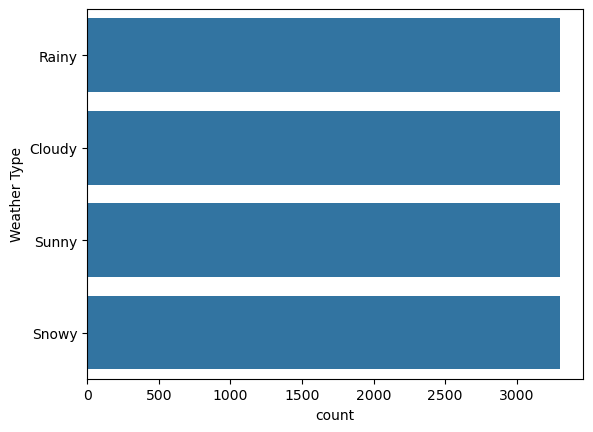

In [6]:
sns.countplot(df['Weather Type'])

<Axes: >

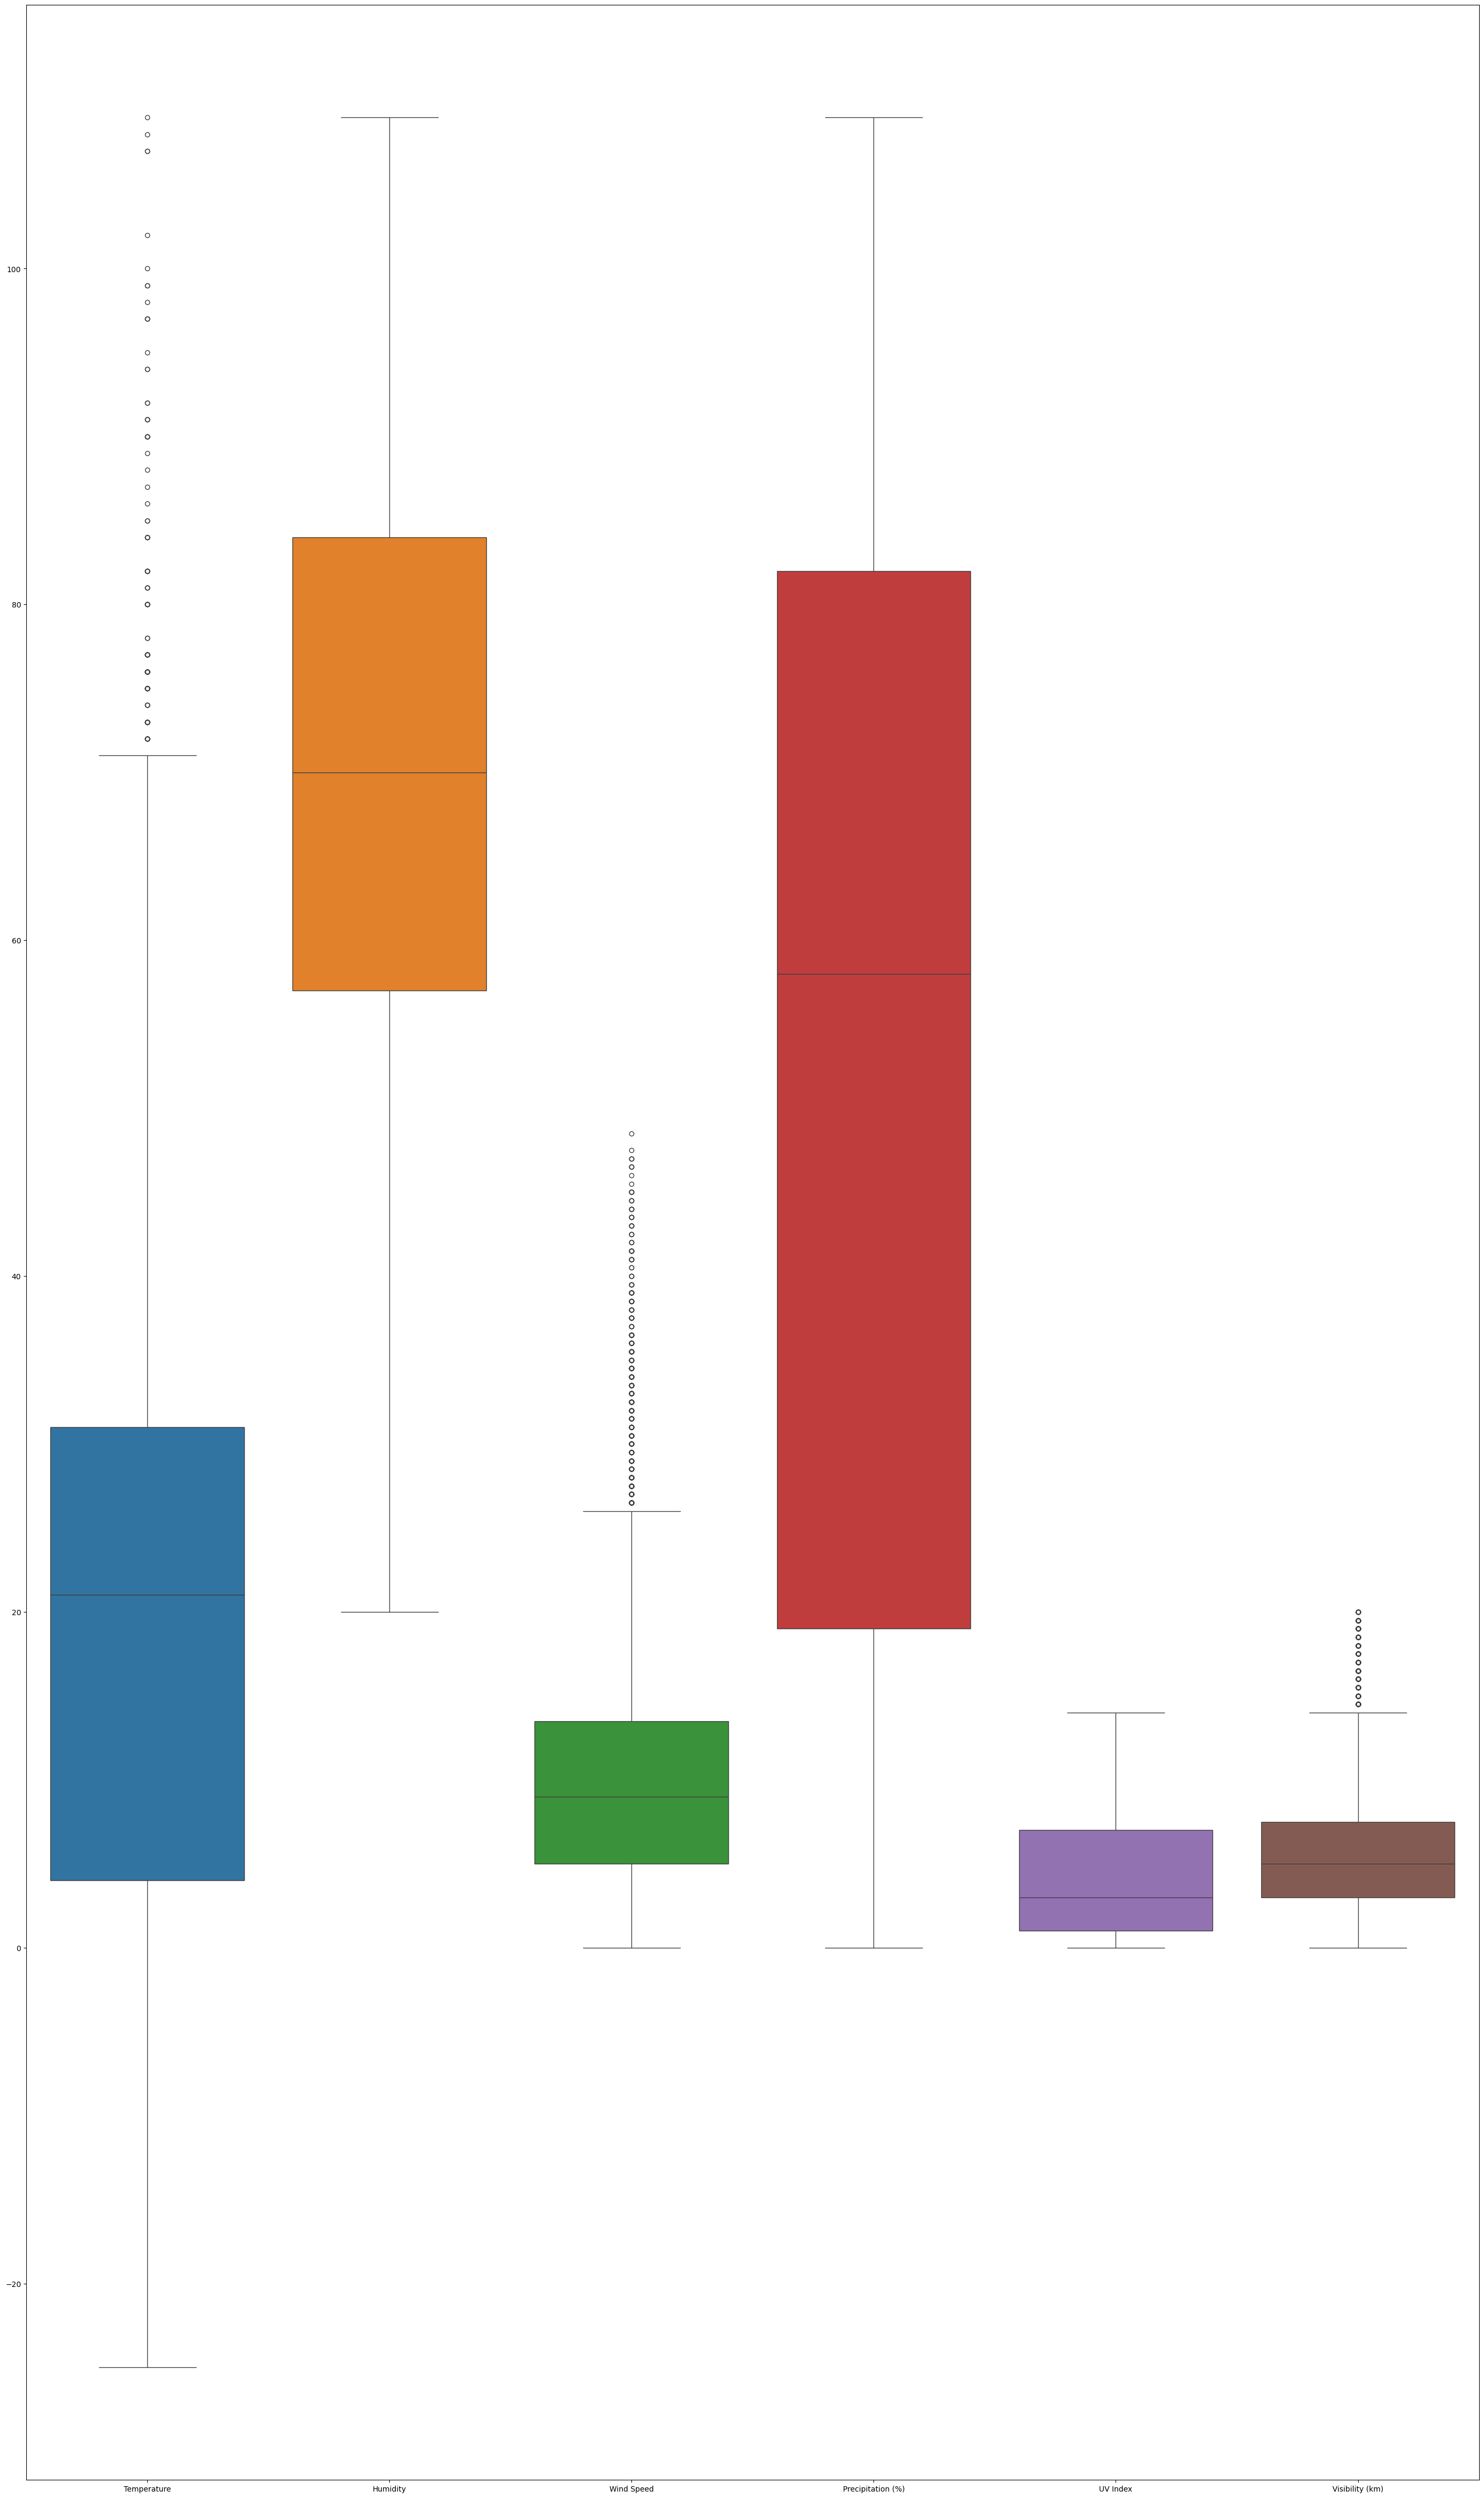

In [7]:
plt.figure(figsize=(35,60))
sns.boxplot(data=df)

In [8]:
cat_cols = ['Season', 'Location','Cloud Cover']
df = pd.get_dummies(df,columns=cat_cols,dtype=int)
df.head()


,Temperature,Humidity,Wind Speed,Precipitation (%),UV Index,Visibility (km),Weather Type,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy
0,14.0,73,9.5,82.0,2,3.5,Rainy,0,0,0,1,0,1,0,0,0,0,1
1,39.0,96,8.5,71.0,7,10.0,Cloudy,0,1,0,0,0,1,0,0,0,0,1
2,30.0,64,7.0,16.0,5,5.5,Sunny,0,1,0,0,0,0,1,1,0,0,0
3,38.0,83,1.5,82.0,7,1.0,Sunny,0,1,0,0,1,0,0,1,0,0,0
4,27.0,74,17.0,66.0,1,2.5,Rainy,0,0,0,1,0,0,1,0,0,1,0


In [9]:
le = LabelEncoder()
df['Weather Type'] = le.fit_transform(df['Weather Type'])
df['Weather Type']

0        1
1        0
2        3
3        3
4        1
        ..
13195    1
13196    2
13197    0
13198    2
13199    1
Name: Weather Type, Length: 13200, dtype: int32

<Axes: >

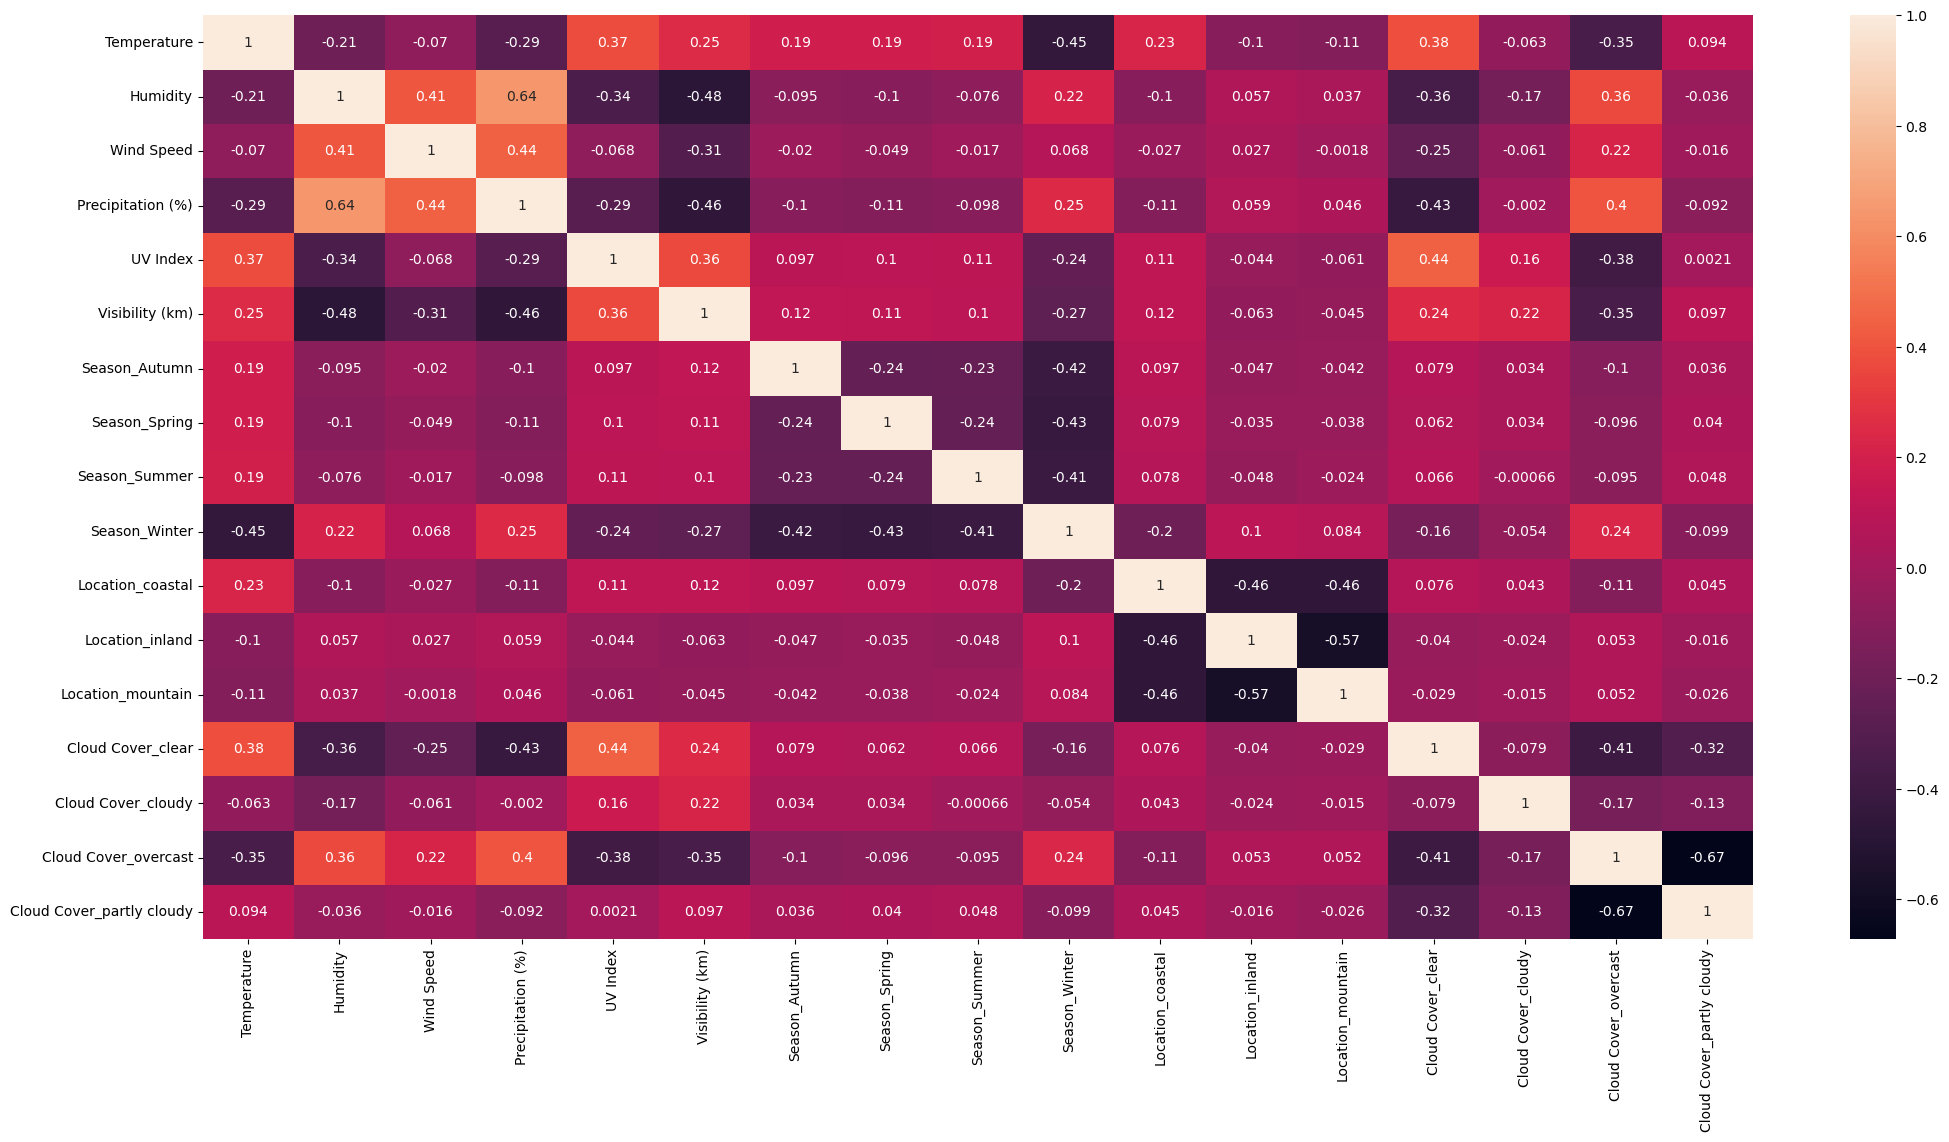

In [10]:
plt.figure(figsize=(25,12))
corr=df.drop("Weather Type",axis=1).corr()
sns.heatmap(corr, annot=True)


In [11]:
x=df.drop("Weather Type",axis=1)
y=df["Weather Type"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_val,y_train,y_val=train_test_split(x_train, y_train,test_size=0.1,random_state=42)

In [12]:
pipe = Pipeline([('select',SelectKBest(score_func=f_regression)),
('scale',MinMaxScaler())
,('knn',KNeighborsClassifier())
])

In [13]:
params={
    'select__k':[5,10,12,14,16],
    'knn__n_neighbors':[3,5,7,9,11],
    'knn__p':[1,2]
}

In [14]:
grid_search=GridSearchCV(pipe,param_grid=params,cv=5,scoring='accuracy')
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('select',
                                        SelectKBest(score_func=<function f_regression at 0x000002097FEC7600>)),
                                       ('scale', MinMaxScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7, 9, 11], 'knn__p': [1, 2],
                         'select__k': [5, 10, 12, 14, 16]},
             scoring='accuracy')

In [15]:
grid_search.best_params_

{'knn__n_neighbors': 3, 'knn__p': 1, 'select__k': 16}

In [16]:
best_model=grid_search.best_estimator_

In [17]:
y_train_pred=best_model.predict(x_train)
y_val_pred=best_model.predict(x_val)
y_pred=best_model.predict(x_test)

In [18]:
acc=accuracy_score(y_test,y_pred)
print("accuracy=",acc*100,'%')

#f1=f1_score(y_test,y_pred)
#print("F1cscore=",f1*100,'%')
#pre=precision_score(y_test,y_pred)
#print("precision=",pre*100,'%')
# rec=recall_score(y_test,y_pred)
# print("recall=",rec*100,'%')
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
# disp.plot(cmap=plt.cm.Blues)
# plt.show()


accuracy= 88.97727272727273 %


In [19]:
acc1=accuracy_score(y_val,y_val_pred)
print("accuracy=",acc1*100,'%')
# f11=f1_score(y_val,y_val_pred)
# print("F1cscore=",f11*100,'%')
# pre1=precision_score(y_val,y_val_pred)
# print("precision=",pre1*100,'%')
# rec1=recall_score(y_val,y_val_pred)
# print("recall=",rec1*100,'%')
# cm = confusion_matrix(y_val, y_val_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
# disp.plot(cmap=plt.cm.Blues)
# plt.show()


accuracy= 88.4469696969697 %
